## Tutorial: calculating ammonia's ionization potentials with a variational quantum algorithm

In this tutorial notebook, we will exemplify the use of a variational algorithm to estimate the ionization energy of an ammonia molecule at equilibrium geometry. In doing so, we will perform two single point energy calculations, one for the neutral and one for the ionized states, where for the latter an open shell doublet spin state is required. The ionization energy will be then obtained as the energy difference between the cation and neutral species.


### Hardware requirements
The basic version of this tutorial, i.e. without the modifications suggested as exercises below, requires at least 1GB of main memory to run. Furthermore, it is recommended to run this on a machine with at least 4 physical cores for the best user experience.

We start with importing the relevant modules. All the classes and methods needed will be found in the `qrunch` package. Its full documentation can be found [here](https://qrunch.docs.kvantify.net/index.html).

In [133]:
from pathlib import Path
import qrunch as qc

output_path = Path("output")
output_path.mkdir(exist_ok=True, parents=True)

### Setting up the experiment

The starting point for our tutorial is the specification of the .xyz file containing the atomic coordinates for ammonia. This is done via `Path` as exemplified below as this will be accepted as input for our builders. We additionally specify the basis-set that will be use in the calculations. The cc-pvDZ basis-set is chosen for this tutorial.

In [134]:
structure_path = Path("data/nh3_eq.xyz")
basis_set = "cc-pvdz"

Now we will build our molecular configuration for both the neutral and cation species, the latter being a doublet spin state. In Qrunch the spin state of a molecular system is specified as the difference between the number of alpha and beta electrons via the `spin_difference` argument.

In [135]:
neutral_configuration = qc.build_molecular_configuration(
    molecule=structure_path,
    basis_set=basis_set,
    charge=0,
    spin_difference=0,
)

cation_configuration = qc.build_molecular_configuration(
    molecule=structure_path,
    basis_set=basis_set,
    charge=1,
    spin_difference=1,
)


### Creating the problem with the problem builder

The next step is to build the problems containing all the chemistry relevant information that we defined up to here, as well as new ones such as the active spaces for neutral and cation problems needed for our ionization calculation.

We will use the [fluent build pattern](https://qrunch.docs.kvantify.net/docs/explanations/builder_pattern.html) to construct what we call the `problem_builder_creator` and we define one for each of the configurations defined above. The logic behind this object, is that we typically start by specifying broad definitions/options for then narrowing more and more the choices as it will hopefully soon be clear with the practical examples given.

As the system of interest is quite small, we can avoid the use of the projective embedding framework (see the [Dehalogenase](https://github.com/Kvantify/qrunch_tutorials/blob/main/dehalogenase-tutorial/dehalogenase_reaction_tutorial.ipynb) and [COF-999](https://github.com/Kvantify/qrunch_tutorials/blob/main/cof-999-tutorial/cof-999-tutorial.ipynb) tutorials for its use) and just focus on a ground state problem that includes the whole system. At this point we can modify our problem with active space, defined by two integers, the number of active orbitals and active alpha electrons respectively. The beta electrons are internally counted and adjusted based on the total charge and spin of the system, so no need for the explicit specification.
For this tutorial, we will employ an active space defined by 6 active orbitals and 8 active electrons (thus 4 active alpha electrons).

Note that if the problem was not modified with the active space definition, the full-CI space would be assumed by default.

In [136]:
problem_builder_neutral_creator = (
    qc.problem_builder_creator()
    .ground_state()
    .standard()
    .add_problem_modifier()
    .active_space(6, 4)
)

problem_builder_cation_creator = (
    qc.problem_builder_creator()
    .ground_state()
    .standard()
    .add_problem_modifier()
    .active_space(6, 4)
)

From the creators defined above, we can finally create the problem builders that in turn are used to build the final problem for both neutral and cation species. In doing so, we use the `.build_unrestricted` method since the cation involves an open shell doublet state. Note that, for the neutral molecule the `.build_restricted` could have equally been used as for closed shell molecules near the equilibrium geometry, the restricted and unrestricted treatments are degenerate.

In [137]:
problem_builder_neutral = problem_builder_neutral_creator.create()
problem_builder_cation = problem_builder_cation_creator.create()

problem_neutral = problem_builder_neutral.build_unrestricted(neutral_configuration)
problem_cation = problem_builder_cation.build_unrestricted(cation_configuration)


After building the problems, we can inspect the electron configuration to verify that the alpha and beta components are as expected.

In [138]:
print(
    "The neutral molecule has {} alpha and {} beta electrons.".format(
        problem_neutral.electron_configuration.number_of_alpha_electrons,
        problem_neutral.electron_configuration.number_of_beta_electrons,
    )
)
print(
    "The cation molecule has {} alpha and {} beta electrons.".format(
        problem_cation.electron_configuration.number_of_alpha_electrons,
        problem_cation.electron_configuration.number_of_beta_electrons,
    )
)

The neutral molecule has 4 alpha and 4 beta electrons.
The cation molecule has 4 alpha and 3 beta electrons.


### Setting up and running the quantum algorithm

The key components of the calculation such as orbitals and active space definition have been created and are used to define the electronic Hamiltonian of which we wish to seek a ground state approximation as close as possible to its exact form via a variational quantum algorithm. Moving to the quantum section, we need to specify key objects such as `sampler` and `estimator`. The  sampler will be used to select gates, sampling from hardware or simply from the state vector in this case, while `estimator` defines the way the energy is evaluated at each new added gate, thus iteration. In our approach, the energy will be estimated from the state vector through a classical simulation. Alternatively, one could calculate expectation values from sampling quantum hardware, although this is quite challenging due to the high noise affecting current hardware. 

We will choose`excitation_gate` for both the `estimator` and `sampler` as shown in the code snippet below. This is Kvantify's proprietary simulator exploiting the particle conserving nature of electronic excitations typically encountered in quantum chemistry, notably decreasing the computational efforts of state vector simulations. 

In [139]:
sampler = qc.sampler_creator().excitation_gate().create()

In [140]:
estimator = qc.estimator_creator().excitation_gate().create()

Another key object is the `gate_selector`, which is used in ranking excitation gates contained in the the gate pool defined inside the active space. We will employ our own patented `fast` gate selector. More details about the FAST-VQE algorithm are found in reference ([FAST-VQE algorithm](https://qrunch.docs.kvantify.net/docs/explanations/adaptive_vqe.html#fast-vqe-a-resource-efficient-adaptive-strategy)).

Note, that, we will not sample from the state vector (`.with_shots(None)`), instead we will perform an exact simulation.

In [141]:
gate_selector = (
    qc.gate_selector_creator().fast().with_sampler(sampler).with_shots(None).create()
)

These will be used in connection to the `fast_vqe_calculator` that is required for the actual calculation. Below, its definition together with some specific `adaptive_options` we want to set, in order to be able to run the complete set of iterations requested.

In [142]:
adaptive_options = qc.options.IterativeVqeOptions(
    max_iterations=60,
    force_all_iterations=True,
)

fast_vqe_calculator = (
    qc.calculator_creator()
    .vqe()
    .iterative()
    .standard()
    .with_estimator(estimator=estimator)
    .with_options(options=adaptive_options)
    .with_gate_selector(gate_selector=gate_selector)
    .create()
)

We are now ready to run the calculation and this is done by using the `fast_vqe_calculator` in connection to the problems defined earlier for the neutral and cation (ionized) case. 

We call the outputs of these runs `result_` where the underscore is followed by the specific problem name. 

In [143]:
result_neutral = fast_vqe_calculator.calculate(problem_neutral)
result_cation = fast_vqe_calculator.calculate(problem_cation)

### Extracting and plotting results

We can now extract our results into array suitable for plotting. In particular, we want to plot the ionization energy as a function of the number of iterations. To do so we need to extract `total_energy_per_macro_iteration` from both `result_neutral` and `result_cation` as NumPy arrays and these are then used to define the `ionization_energy_per_iteration` array. Note that you can extract a broad range of information from the `result_` classes. Try and type `result_neutral.` for exploring the structure of the class, provided by the interactive completion feature of your Integrated Development Environment.

In [144]:
import numpy as np
import matplotlib.pyplot as plt

energies_neutral = np.array(result_neutral.total_energy_per_macro_iteration.values)
energies_cation = np.array(result_cation.total_energy_per_macro_iteration.values)
ionization_energy_per_iteration = energies_cation - energies_neutral

Finally, the evolution of the ionization energy a function of the number of iterations is plotted as follows

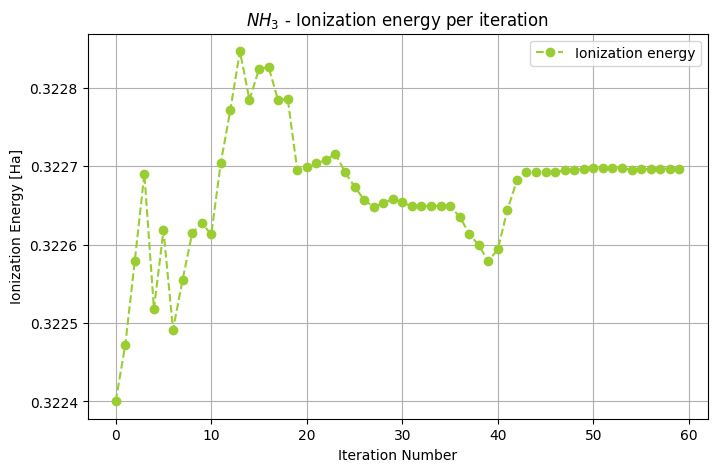

In [145]:
plt.figure(figsize=(8, 5))
plt.plot(
    ionization_energy_per_iteration,
    marker="o",
    label="Ionization energy",
    linestyle="--",
    color="yellowgreen",
)

plt.xlabel("Iteration Number")
plt.ylabel("Ionization Energy [Ha]")
plt.title("$NH_3$ - Ionization energy per iteration")
plt.grid()
plt.legend()
plt.show()

### Now it's your turn 
In this section, you are invited to play with different settings and to observe the effects on the final results. Below some ideas:

1) Is the calculation converged? You can try to increase the number of iterations and plot the extended results. 

2) Try to enlarge the active space and repeat the calculation by keeping the same number of iterations (55). Do still see convergence and if not what is your explanation? 

Additionally, you can explore the effects that solvation has on the resulting ionization energy by means of a polarizable continuum model. Below an example of how to use the Integral Equation Formalism with Polarized Continuum Model (IEF PCM) model in the definition of our molecular configurations. The dielectric constant of water is given in the following example. For the sake of simplicity, only the `neutral_configuration` is shown as for the cation case, the changes are identical.

In [146]:
from qrunch.chemistry.molecule.solvent import SolventPCM, PCMMethod

neutral_configuration = qc.build_molecular_configuration(
    molecule=structure_path,
    basis_set=basis_set,
    charge=0,
    spin_difference=0,
    solvent=SolventPCM(
        dielectric_constant=78.4,
        method=PCMMethod.IEF_PCM,
    ),
)

### Running on a real quantum hardware
Until now, the tutorial covered uniquely state vector simulations. It could be interesting to run the same ionization potential calculations on a real quantum hardware, let's say Rigetti Ankaa-3 which is available via Amazon Braket. This requires minimal changes that involve the `sampler` object, however, a valid aws account and credentials are required. The `excitation_gate` method used earlier should now be replaced by the following:

In [147]:
from braket.devices import Devices

sampler = (
    qc.sampler_creator()
    .backend()
    .choose_backend()
    .amazon_braket(device=Devices.Rigetti.Ankaa3)
    .create()
)

A last change required to run on Ankaa-3 is the number of shots specified in the `gate_selector` object since we now are interested in sampling our wave function on the device. This can be done as shown in the code snippet below. 

In [148]:
gate_selector = (
    qc.gate_selector_creator().fast().with_sampler(sampler).with_shots(1000).create()
)

Note that the cost of your calculation will depend on the number of shots as well as on the number of iterations plus a small additional cost arising from the task price. We can estimate the cost of a quantum hardware calculation via the `cost` function as shown in the example below.

In [149]:
from qrunch.quantum.backends.amazon.amazon_braket_backend import AmazonBraketBackend

num_shots = 1000
num_adapt_iter = 50
backend = AmazonBraketBackend(device=Devices.Rigetti.Ankaa3)
price_per_iter = backend.cost(num_shots)
estimated_cost = price_per_iter * num_adapt_iter
print(f"Estimated cost of the calculation: ${estimated_cost:.2f}")


Estimated cost of the calculation: $60.00
